In [1]:
# we want to store the training data in the required format for directBC.

# we will store the qs as [marker4_x, marker4_y, marker4_z, 0, marker2_x, marker2_y, marker2_z, 0, ee_x, ee_y, ee_z]
# boundary condition is [ee_x, ee_y, ee_z]
# lammbdas can be created using linspace from 0 to 1 with the same length as the trajectories

In [2]:
import json
import numpy as np

# file_path = "DLO_slinky_1d_70cm_71pts_v1.json"
file_path = "slinky_test4_12pts_v3.json"
output_path = "test_dataset.npz"

Loaded 13 samples


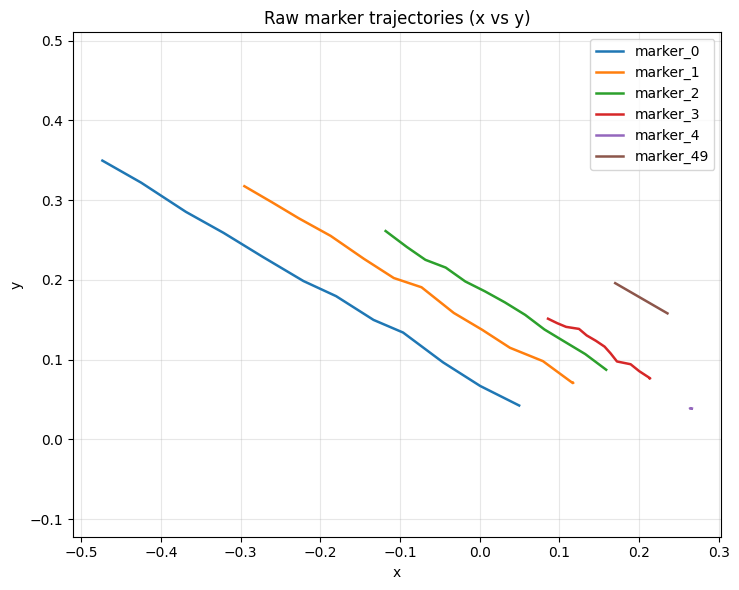

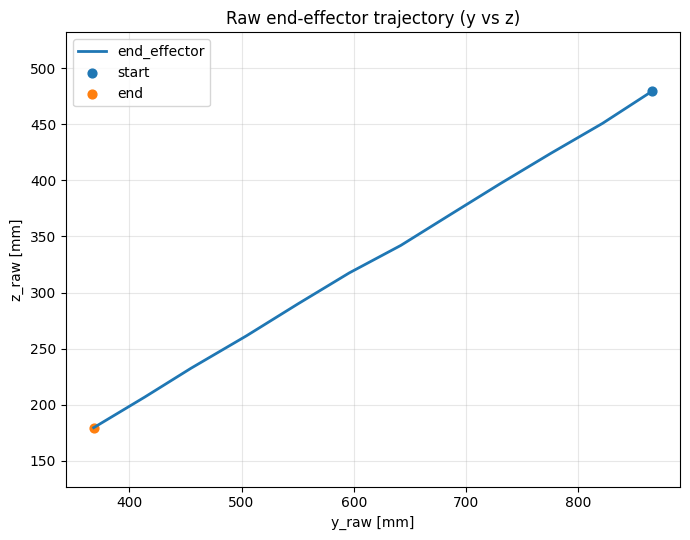

Origin from marker_4 mean:
x0 = 0.26460755118708773
y0 = 0.03888298597511727
z0 = 0.7382881507359537


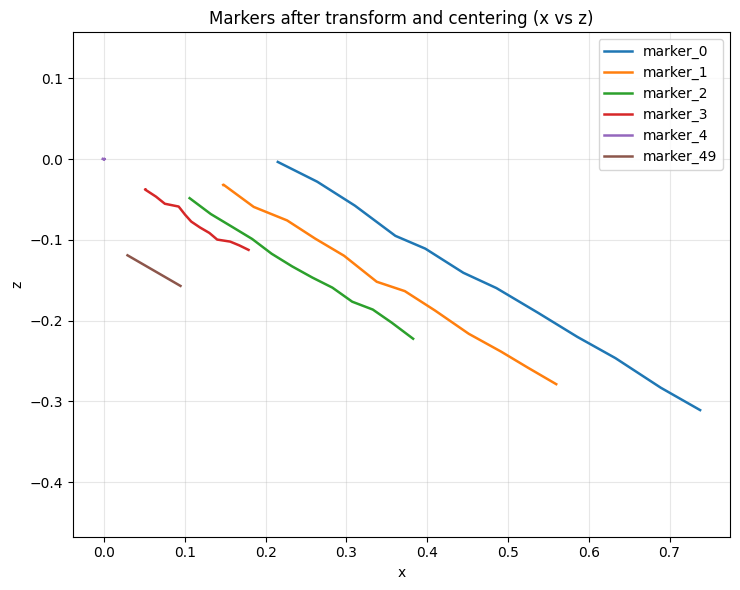

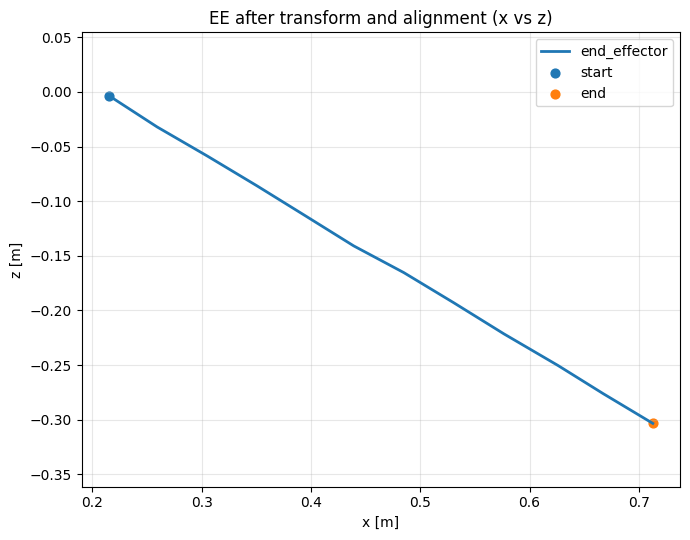

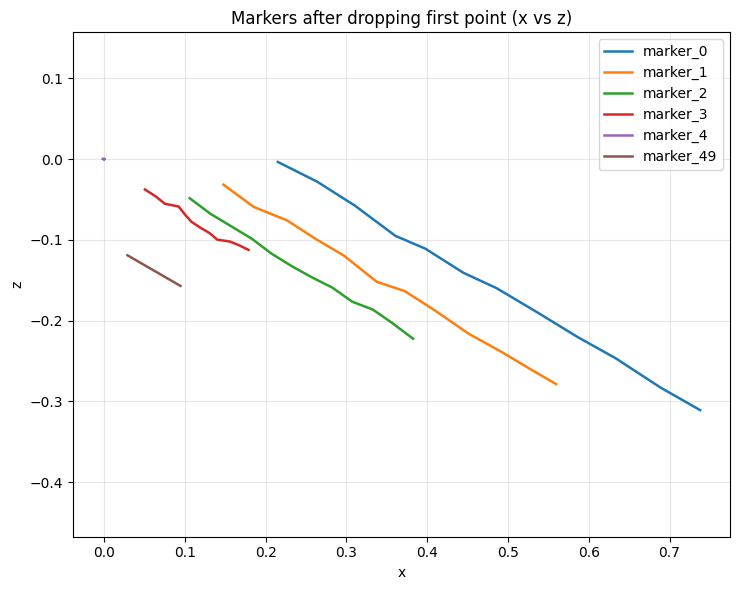

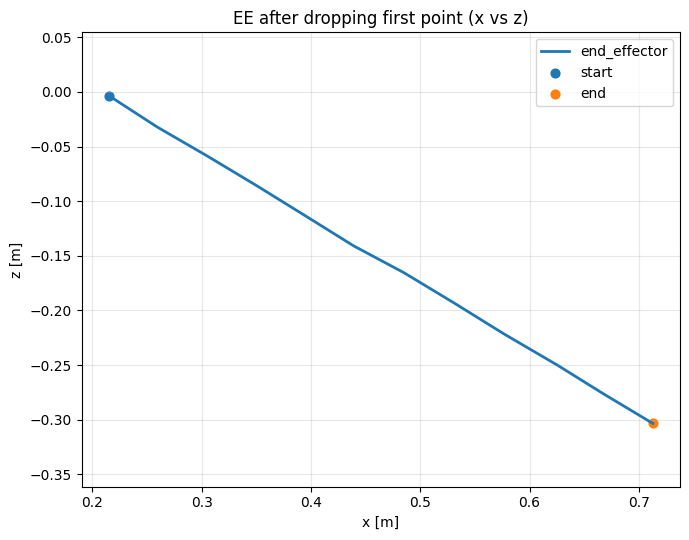

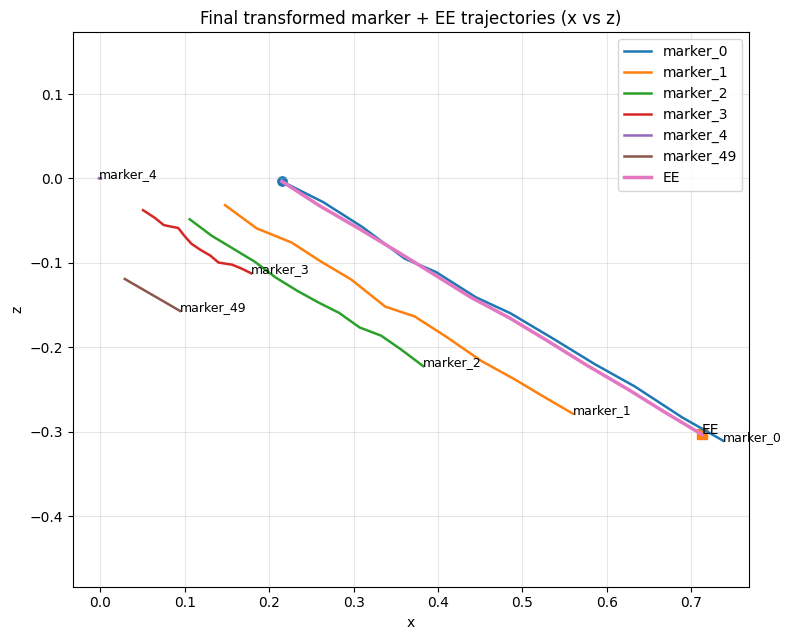

qs shape: (1, 12, 11)
xb shape: (1, 12, 8)
idx_b: [ 0  1  2  3  7  8  9 10]
lambdas shape: (12,)


In [3]:
from extract_data import extract_directbc_dataset, plot_qs_snapshots
qs, xb, idx_b, lambdas = extract_directbc_dataset(input_json_path=file_path, output_npz_path=output_path, reverse_trajectory=False, make_plots=True, drop_first_point=True)

In [4]:
print(qs[0,0,:])

[ 0.          0.          0.          0.          0.10587944  0.
 -0.04835247  0.          0.21512709  0.         -0.00347242]


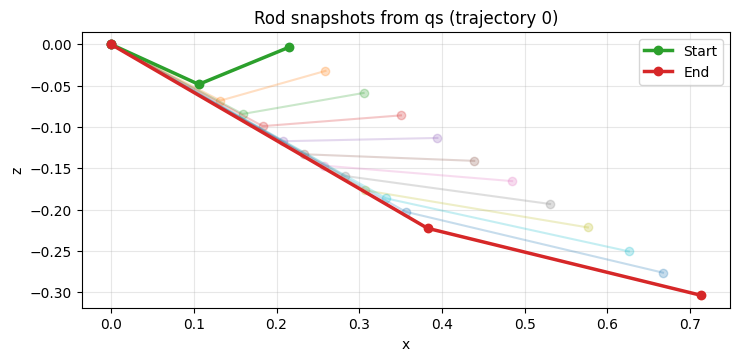

In [5]:
plot_qs_snapshots(qs, every_step=1)

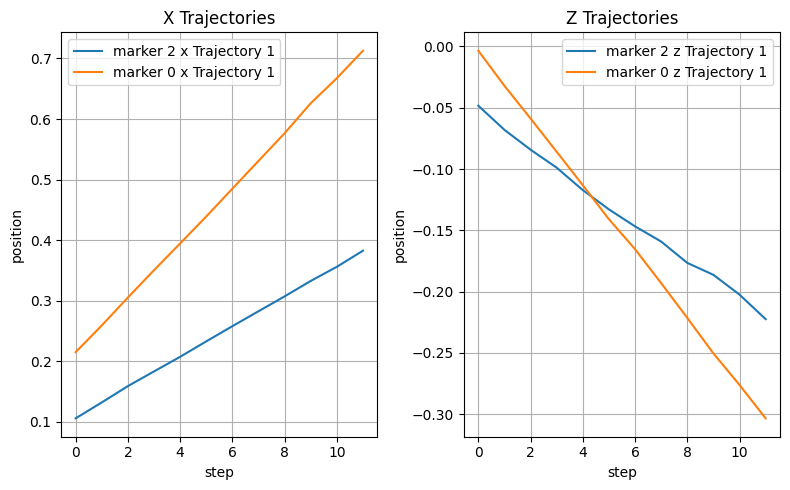

In [6]:
import matplotlib.pyplot as plt

for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, 4], label=f"marker 2 x Trajectory {i+1}")
    plt.plot(qs[i, :, 8], label=f"marker 0 x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, 6], label=f"marker 2 z Trajectory {i+1}")
    plt.plot(qs[i, :, 10], label=f"marker 0 z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()